In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [ ]:
## 1.	Load the dataset and perform basic data exploration.

In [ ]:
df = pd.read_csv('wine.csv')

In [ ]:
df.shape

(178, 14)

In [ ]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df['Type'].unique()

array([1, 2, 3])

In [ ]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target = df['Type']
features = df.drop(columns=['Type'])

In [ ]:
## 2.	Examine the distribution of features using histograms, box plots, or density plots.

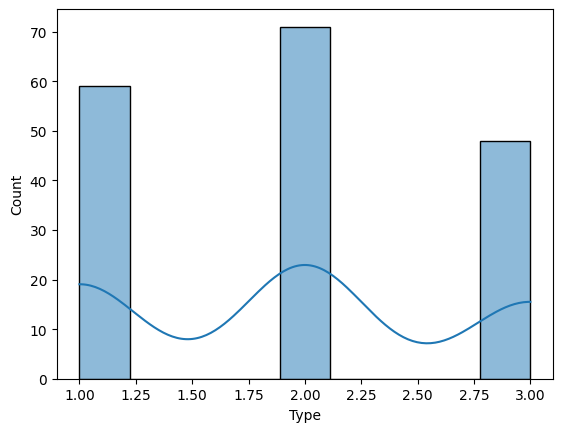

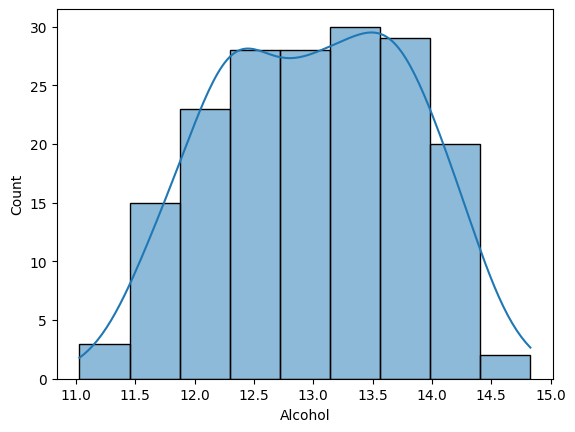

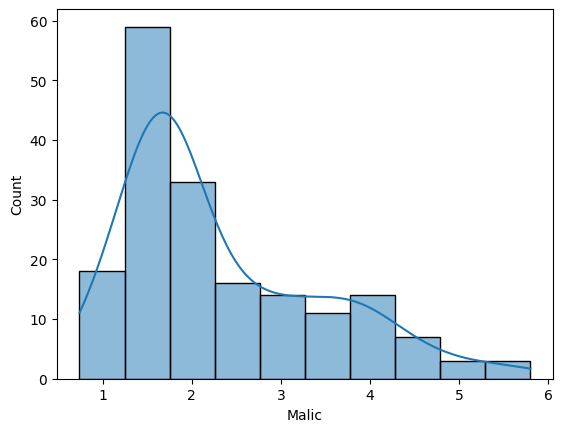

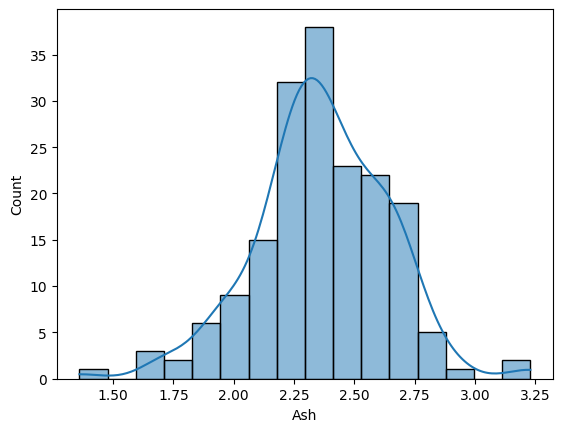

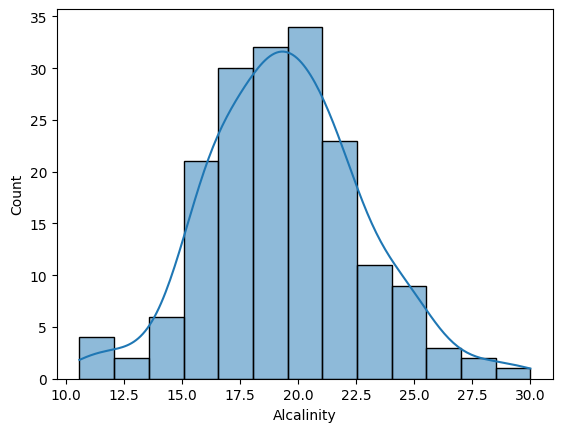

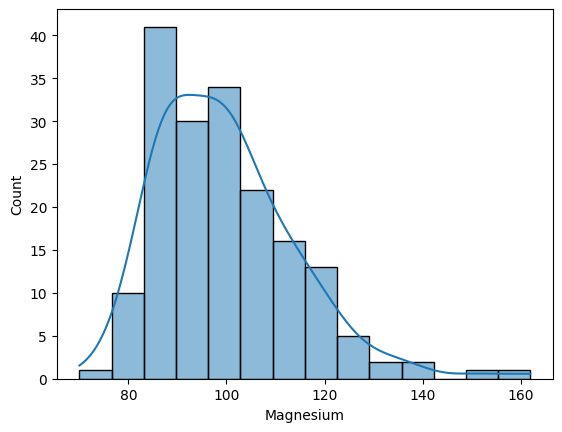

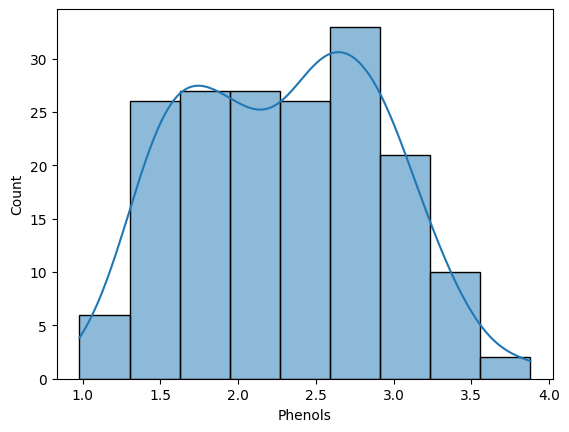

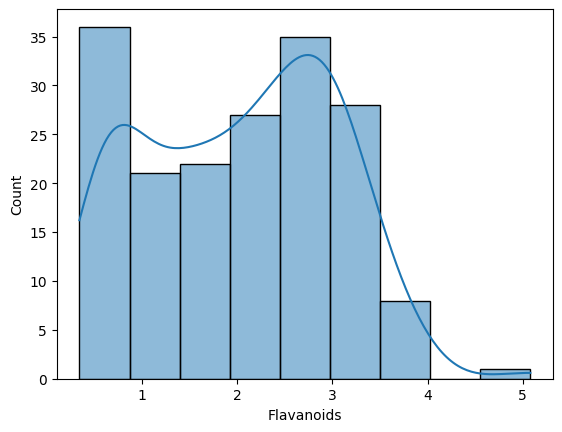

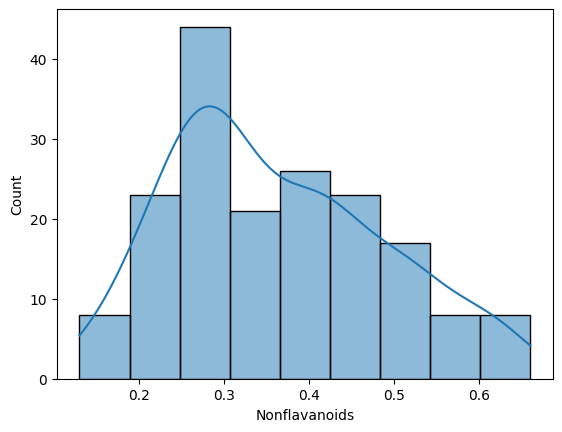

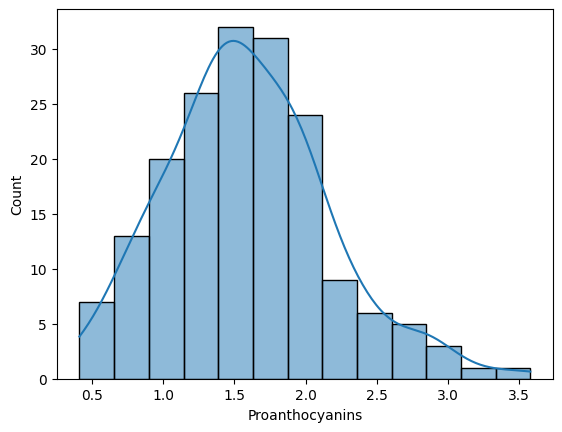

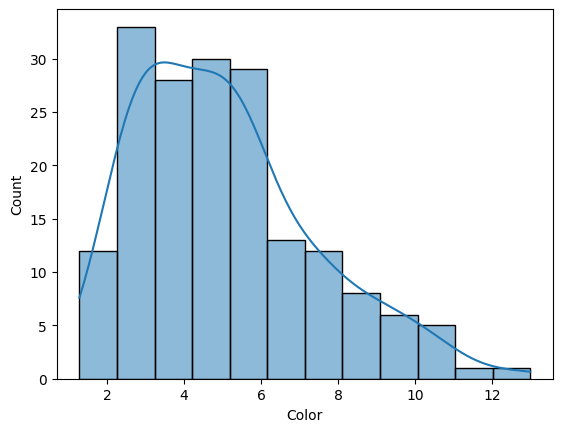

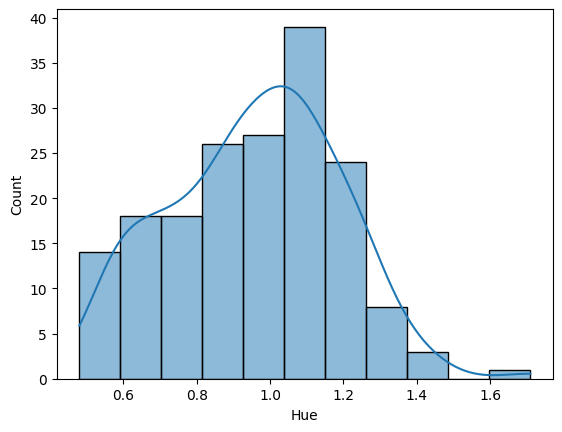

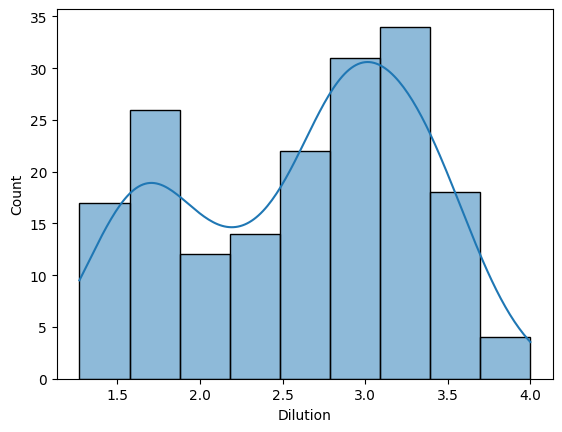

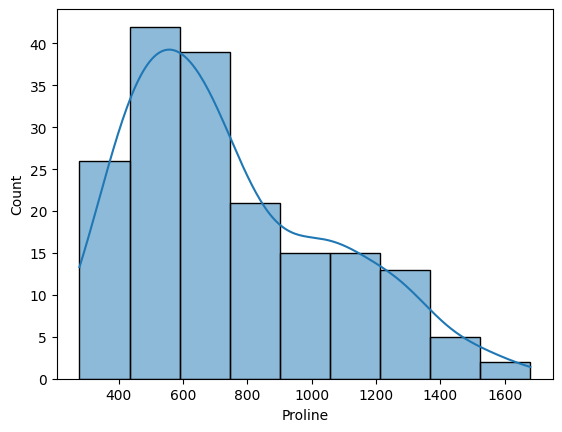

In [ ]:
for col in df.columns:
    sns.histplot(df[col],kde='True')
    plt.show()
    plt.close()

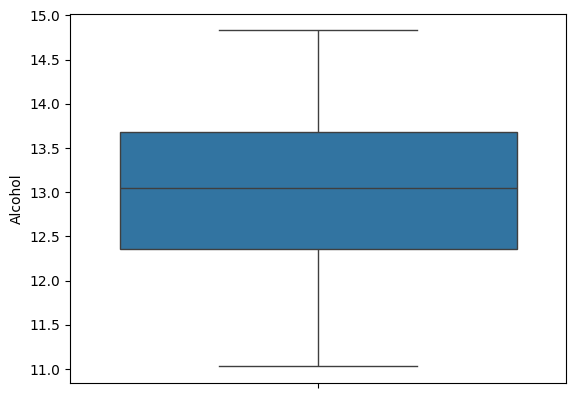

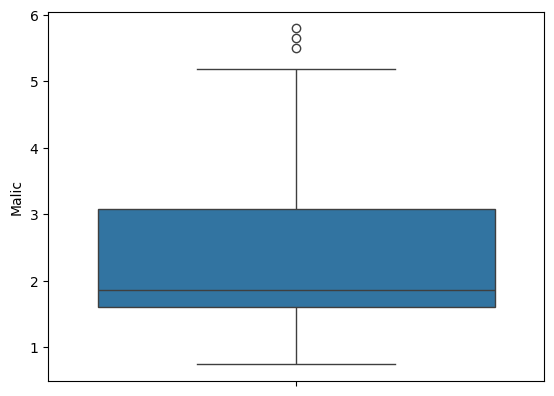

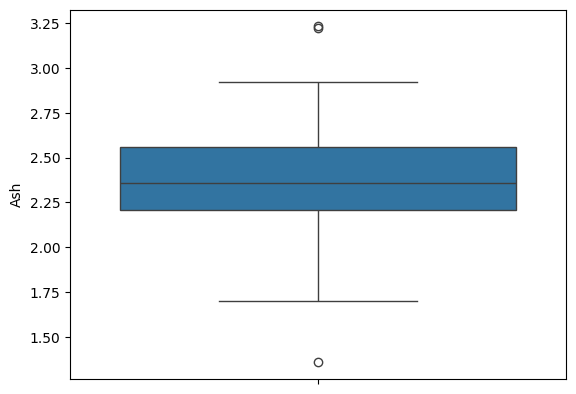

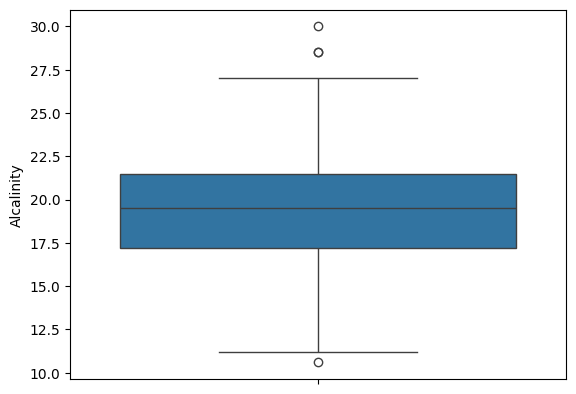

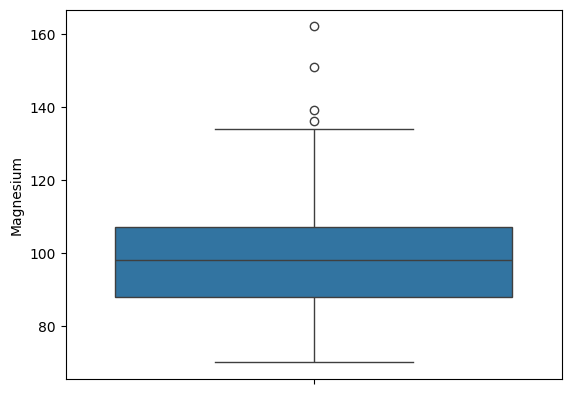

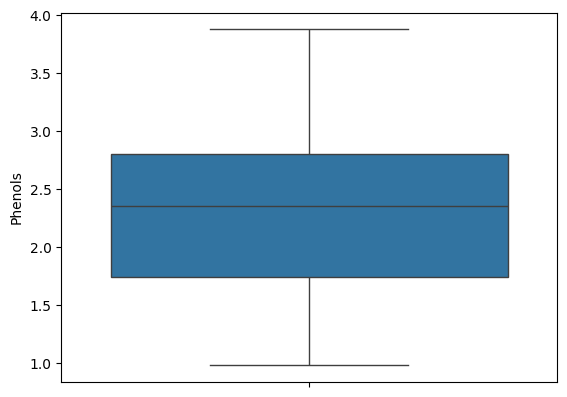

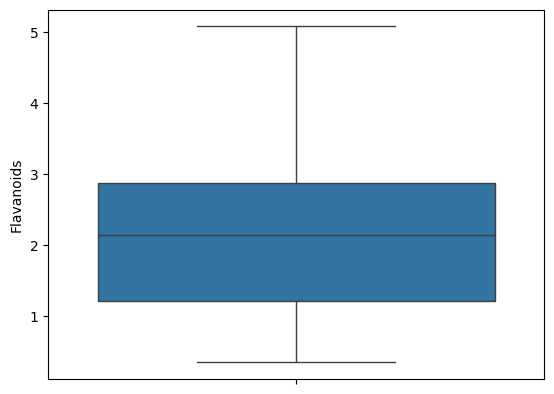

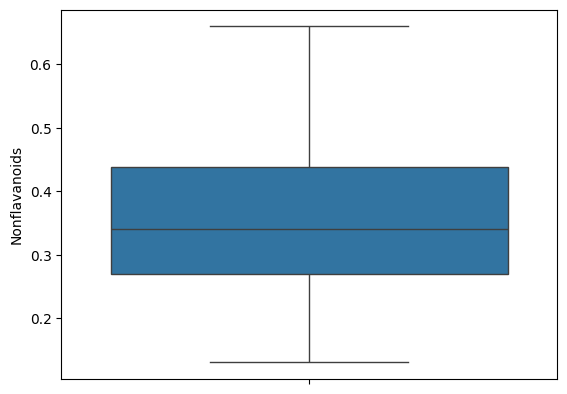

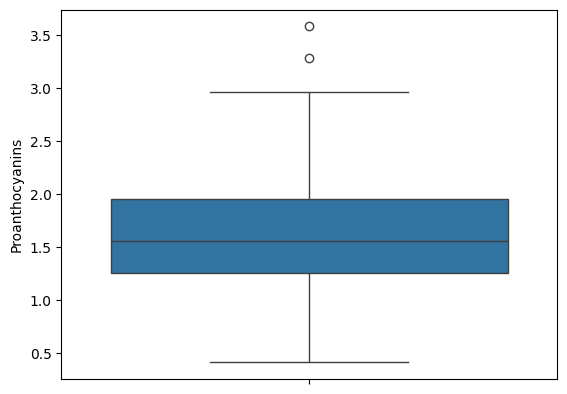

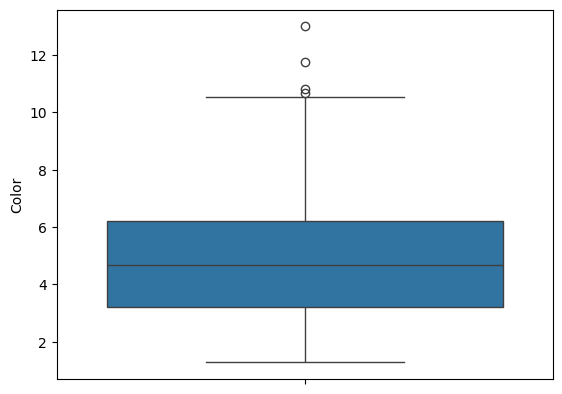

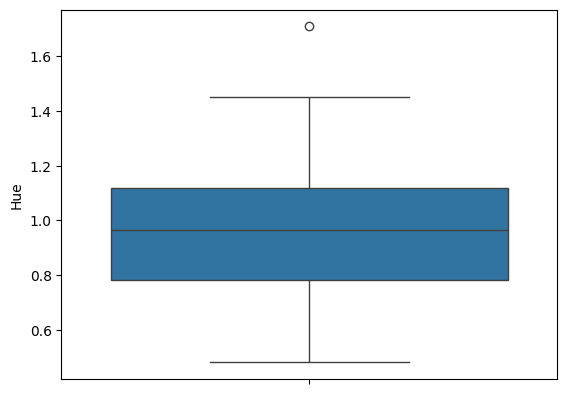

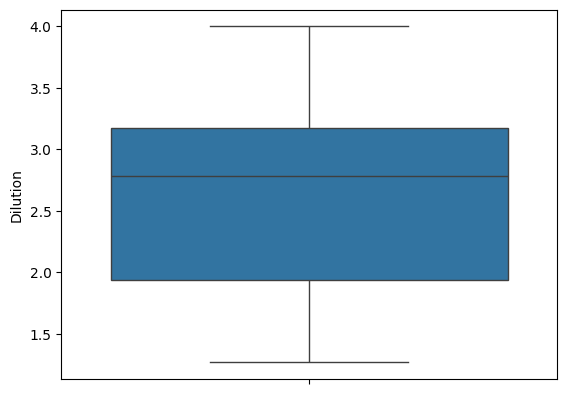

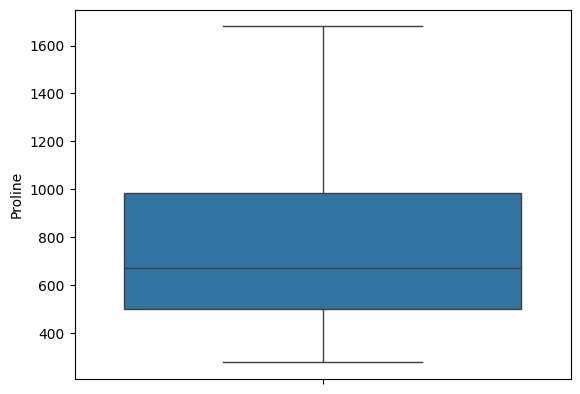

In [ ]:
for col in features.columns:
    sns.boxplot(features[col])
    plt.show()
    plt.close()

From the boxplot we can see many of the feature having outliers.
columns having outliers
- Malic - Postive extreme values
- Ash - Postive and Negative extreme values
- Alcalinity - Positive and negative extreme values
- Magnesium - Positive extreme values
- Proanthocyanins - Positive extreme values
- Color - Positive extreme values
- Hue - Positive extreme values

In [ ]:
## Outlier Capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 -Q1
    lower_extreme = Q1 - 1.5*IQR
    upper_extreme = Q3 + 1.5*IQR
    df[columns] = df[columns].apply(lambda x:lower_extreme if x<lower_extreme else
                                    upper_extreme if x> upper_extreme else x)
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

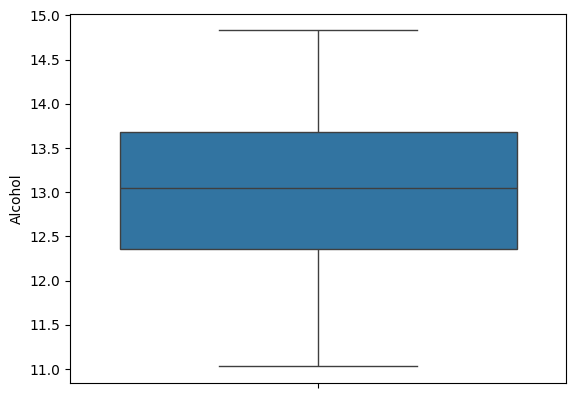

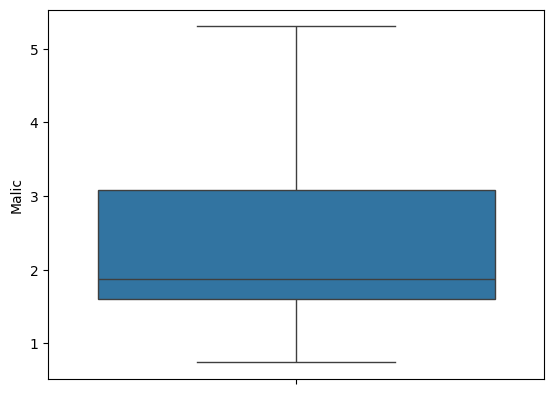

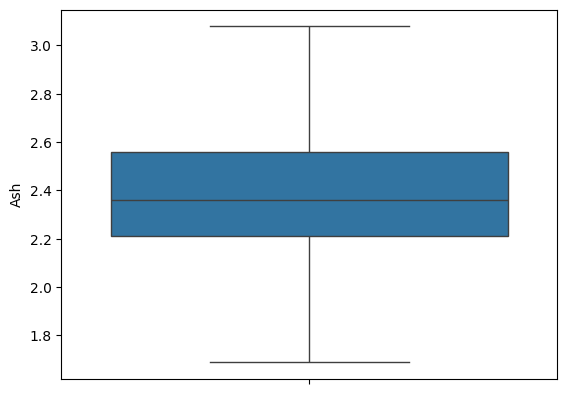

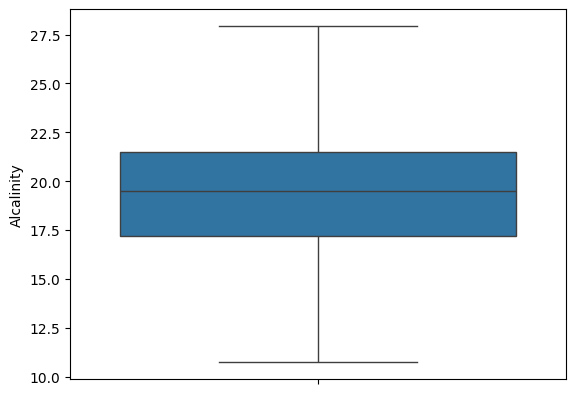

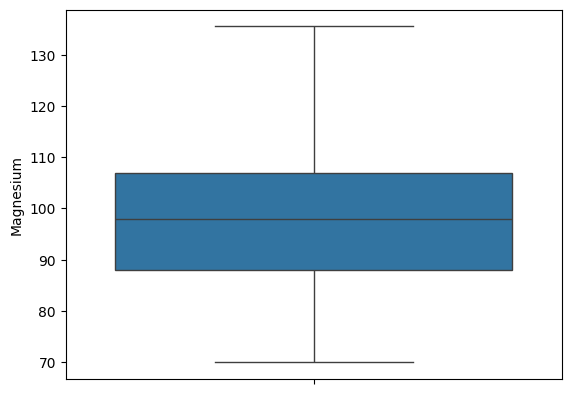

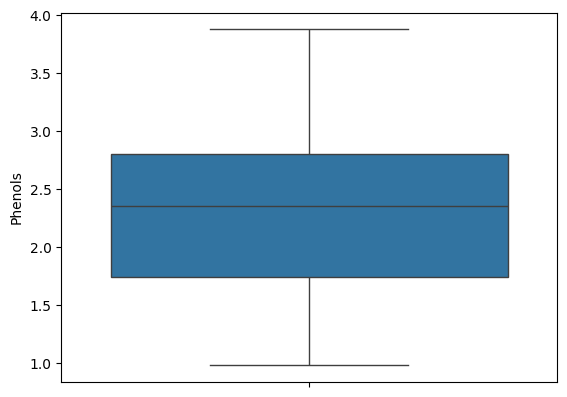

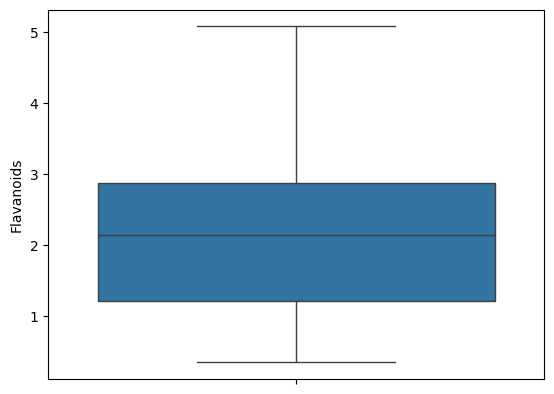

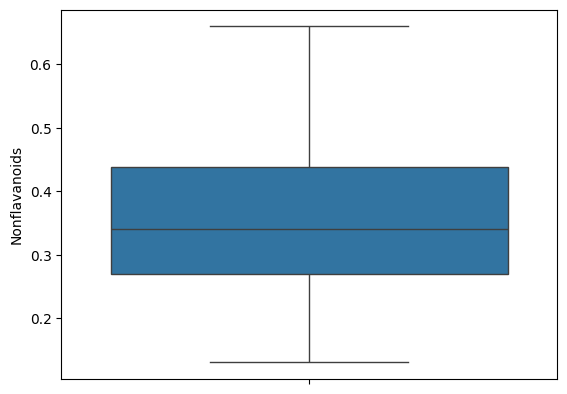

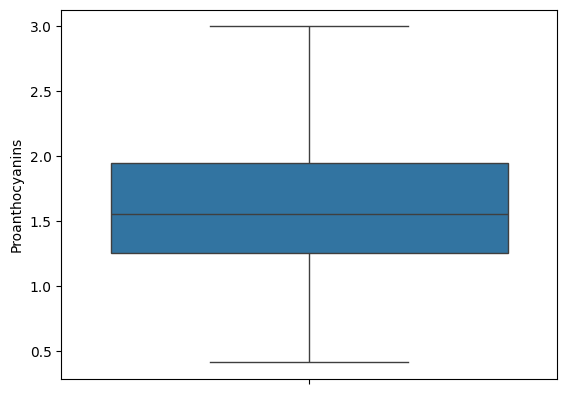

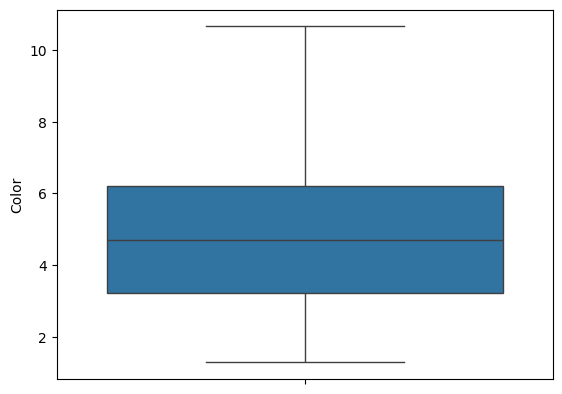

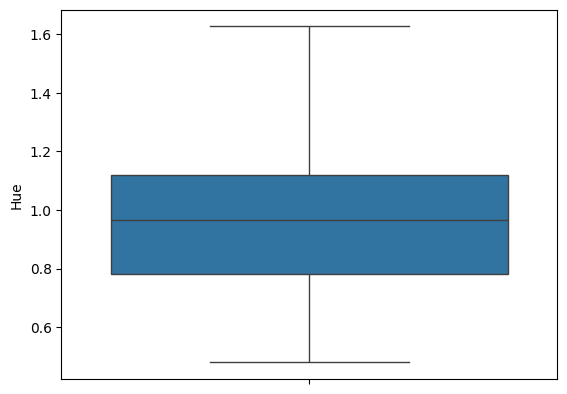

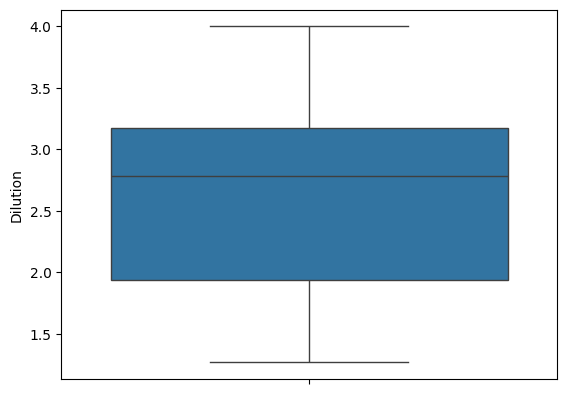

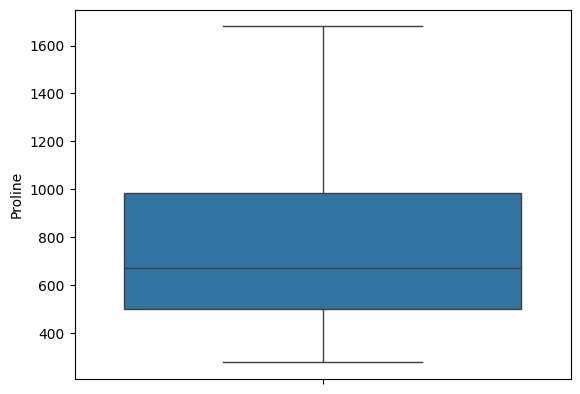

In [ ]:
for col in features.columns:
    sns.boxplot(features[col])
    plt.show()
    plt.close()

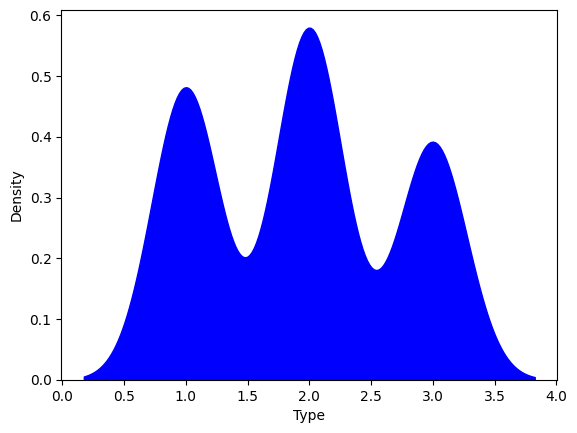

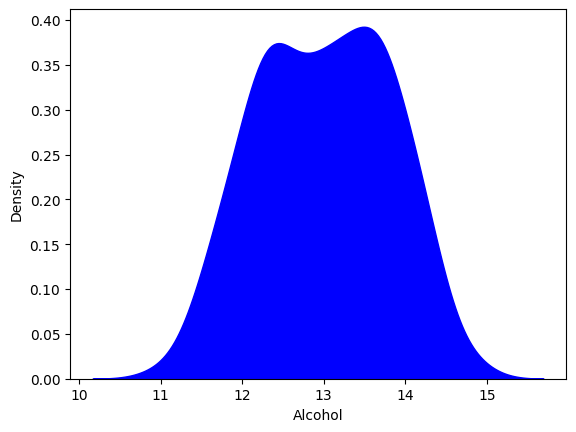

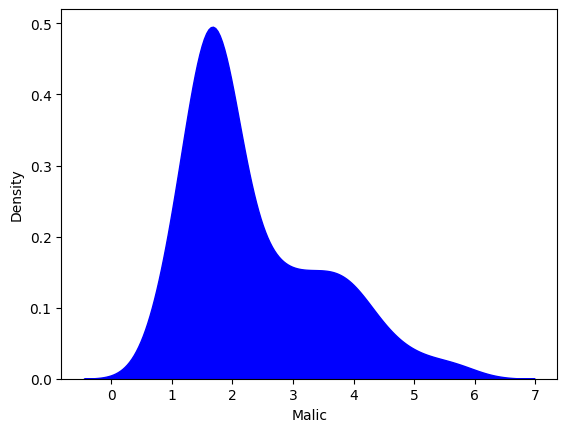

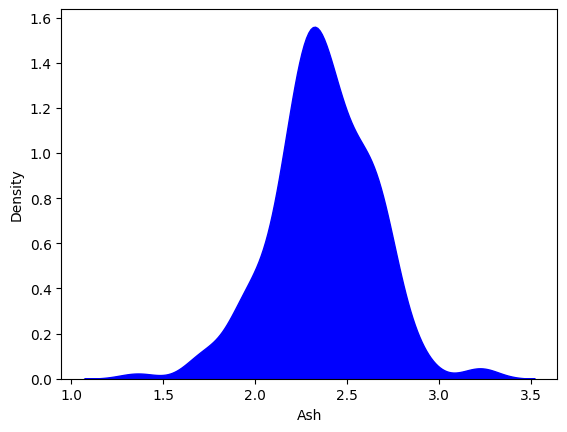

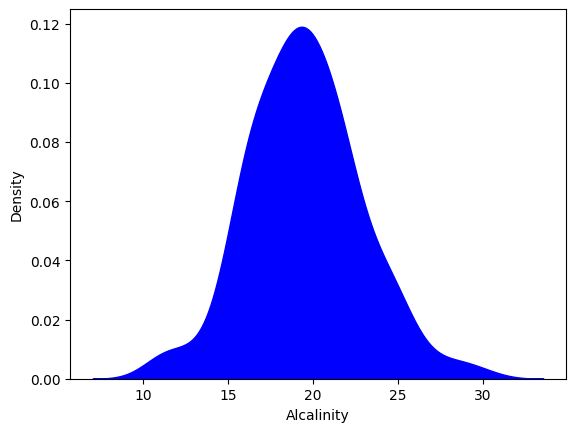

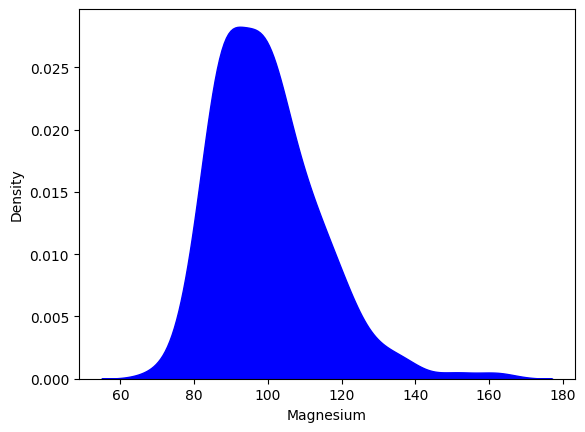

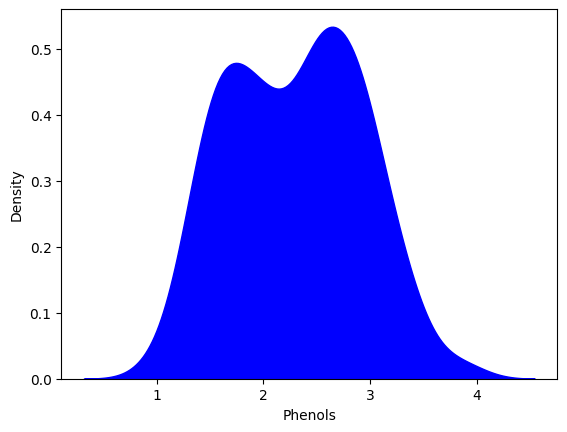

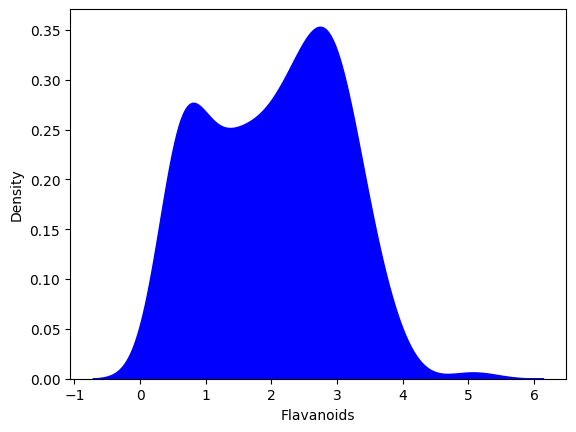

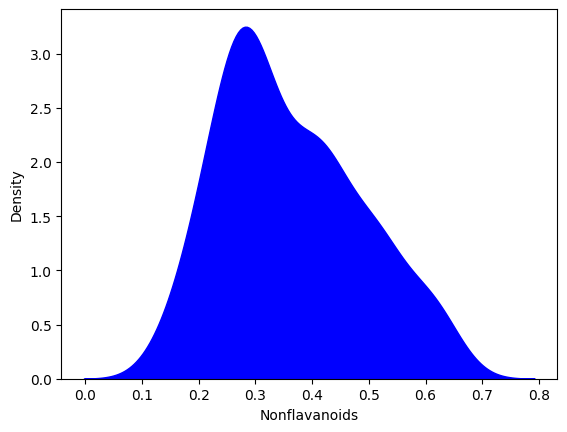

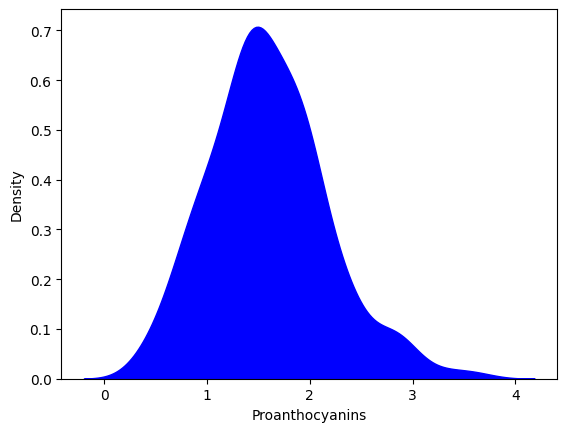

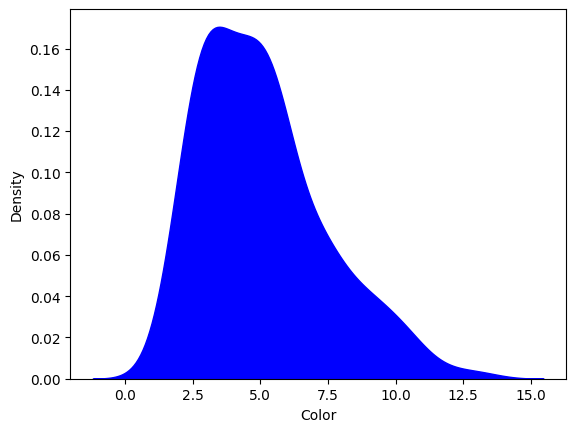

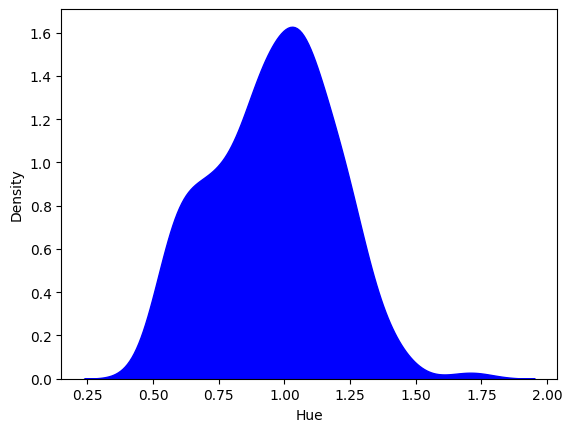

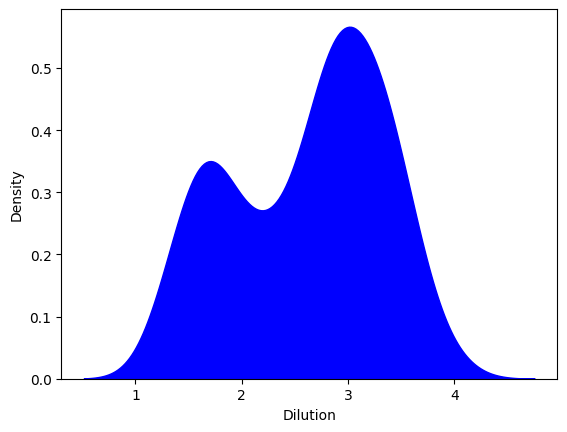

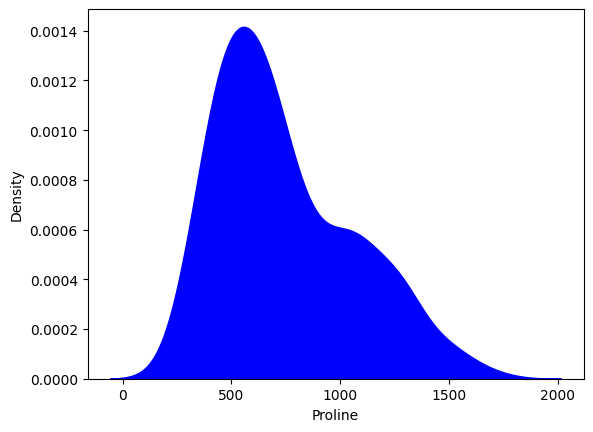

In [ ]:
for col in df.columns:
    sns.kdeplot(df[col],fill=True,color='blue',alpha=1)
    plt.show()
    plt.close()

This density plot is the another version of Histogram. The same findings from Histogram can see from density plot

In [ ]:
## 3.	Investigate correlations between features to understand relationships within the data.

In [ ]:
corr = df.corr()
corr

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoids,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


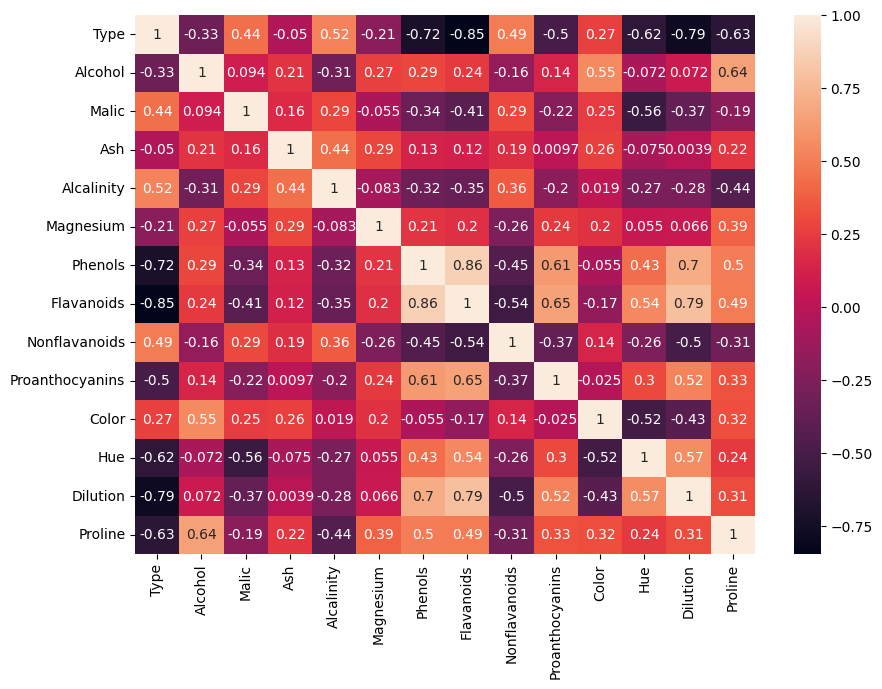

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True)
plt.show()

In [ ]:
## 1. Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(142, 13)
(36, 13)
(142,)
(36,)


In [ ]:
x_train.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
111,12.52,2.43,2.17,21.0,88.0,2.55,2.27,0.26,1.22,2.00,0.90,2.78,325
119,12.00,3.43,2.00,19.0,87.0,2.00,1.64,0.37,1.87,1.28,0.93,3.05,564
170,12.20,3.03,2.32,19.0,96.0,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520
29,14.02,1.68,2.21,16.0,96.0,2.65,2.33,0.26,1.98,4.70,1.04,3.59,1035


In [ ]:
std_sca = StandardScaler()

In [ ]:
x_train.columns

Index(['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [ ]:
x_train[['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline']] = std_sca.fit_transform(x_train[['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline']])
x_train.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
111,-0.619767,0.110249,-0.747286,0.438026,-0.894618,0.321697,0.156083,-0.793780,-0.706635,-1.392928,-0.316405,0.145220,-1.354480
119,-1.251686,1.026705,-1.383459,-0.156617,-0.973965,-0.571144,-0.465056,0.087446,0.485077,-1.728183,-0.174407,0.528145,-0.611245
170,-1.008640,0.660122,-0.185957,-0.156617,-0.259836,-1.788654,-1.598881,0.327780,-1.605002,0.236784,-1.452395,-1.202110,-0.779173
142,0.595462,0.788426,1.310921,1.181331,-0.180488,-1.301650,-1.569303,1.128894,-1.935015,-0.298693,-0.363738,-0.875915,-0.748075
29,1.203077,-0.577093,-0.597598,-1.048583,-0.259836,0.484032,0.215239,-0.793780,0.686751,-0.135722,0.346255,1.293996,0.853457


In [ ]:
x_test = pd.DataFrame(std_sca.transform(x_test),columns=x_test.columns)
x_test.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,-1.689169,-0.228840,0.337951,0.616420,-1.212008,-0.652311,-0.415759,0.968672,-0.468292,-1.020422,0.156924,0.102673,-0.250512
1,0.546853,-0.586257,1.011546,0.884009,-0.815270,0.402864,-0.997461,1.289117,1.255106,2.644100,-1.878391,-1.273022,-0.437098
2,1.324600,-0.760384,-0.185957,-0.810726,-0.339184,-0.246474,0.313833,-0.793780,-0.064944,0.003968,0.961583,0.201950,1.615351
3,-1.300295,-1.117802,-0.260801,0.438026,0.136903,1.669075,0.027912,-1.835229,0.081728,-0.829513,0.109591,0.641605,0.390101
4,1.591950,-0.577093,1.236077,1.627314,-0.101140,0.727534,-0.790414,1.369229,2.006802,2.644100,-1.878391,-1.017739,-0.312707


In [ ]:
## 2. Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

In [ ]:
pca = PCA()

In [ ]:
x_train1 = pca.fit_transform(x_train)
x_test1 = pca.transform(x_test)

In [ ]:
x_train1.shape

(142, 13)

In [ ]:
x_test1.shape

(36, 13)

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(x_train1,y_train)
y_pred = log_reg.predict(x_test1)
accuracy_score(y_test,y_pred)

0.9444444444444444

In [ ]:
exp_var = pca.explained_variance_ratio_
print(exp_var)

[0.36779608 0.20331846 0.11495562 0.07816308 0.05080632 0.04174665
 0.03714476 0.02625847 0.02284969 0.0205229  0.01653364 0.01343889
 0.00646546]


In [ ]:
cum_var = np.cumsum(exp_var)
dict = {'PC':[1,2,3,4,5,6,7,8,9,10,11,12,13],'Cumulative Variance':cum_var}
df_cum = pd.DataFrame(dict)
df_cum

,PC,Cumulative Variance
0,1,0.367796
1,2,0.571115
2,3,0.686070
3,4,0.764233
4,5,0.815040
5,6,0.856786
6,7,0.893931
7,8,0.920189
8,9,0.943039
9,10,0.963562


From the above table shows cumulative variance of all PC's.
- The optimal number of principal components was determined using cumulative explained variance.
- Here i choose optimal number of principal components is 9. Because, it explains 94.30% of the total variance which is a very good balance.
- Why i not take all 13 PC's because Last components add very little new information and They mostly contain noise.



In [ ]:
## Transform the original dataset into the principal components.

In [ ]:
pca = PCA(n_components=9) ## 7 is the optimal number i choosed

x_train_pca = pca.fit_transform(x_train1)
x_test_pca = pca.transform(x_test1)

In [ ]:
x_train_pca = pd.DataFrame(x_train_pca,columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9'])
x_test_pca = pd.DataFrame(x_test_pca,columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9'])

In [ ]:
x_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.557162,-2.049892,-0.091349,0.765701,0.452649,0.719097,-0.592103,0.699100,0.285611
1,-0.849655,-2.213167,-0.437357,1.385915,-0.109483,0.652157,0.906626,-0.717721,-0.342738
2,-3.412289,0.125905,-0.964559,-0.003591,0.777005,0.337549,-0.161950,0.106203,-0.872797
3,-3.160322,0.679780,0.962217,-1.087190,-0.344822,1.237369,-0.562506,0.067553,0.228227
4,2.141868,0.001301,-1.064412,0.150342,-0.512459,0.456985,-0.279434,-0.253188,0.114024


In [ ]:
x_test_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-1.447586,-1.782905,0.790671,-0.421779,-0.647478,-0.254327,0.183470,0.015866,-0.978308
1,-1.549024,2.214042,0.316889,0.826360,-0.993935,-2.774488,-0.712156,0.738857,0.230100
2,1.640211,0.475128,-1.144778,-1.072314,-0.751634,0.482606,-0.725554,-0.763621,-0.202077
3,1.595508,-1.499795,0.278584,0.113966,1.295499,-0.288378,-0.884665,0.483204,-0.494536
4,-0.866690,2.943233,1.066746,0.975537,-0.921393,-2.861699,-0.759650,0.401286,1.155536


In [ ]:
## 1. Apply a clustering algorithm (e.g., K-means) to the original dataset.

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
features.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
features_train = pd.DataFrame(std_sca.fit_transform(features),columns=features.columns)
features_train.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874


In [ ]:
features_train.shape

(178, 13)

In [ ]:
kmeans = KMeans(n_clusters=3,random_state=100)
kmeans.fit(features_train)

KMeans(n_clusters=3, random_state=100)

In [108]:
clusters = kmeans.labels_
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

In [ ]:
## 2. Visualize the clustering results using appropriate plots.

In [109]:
## For visualizing we need to reduce the data to 2d
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_train)

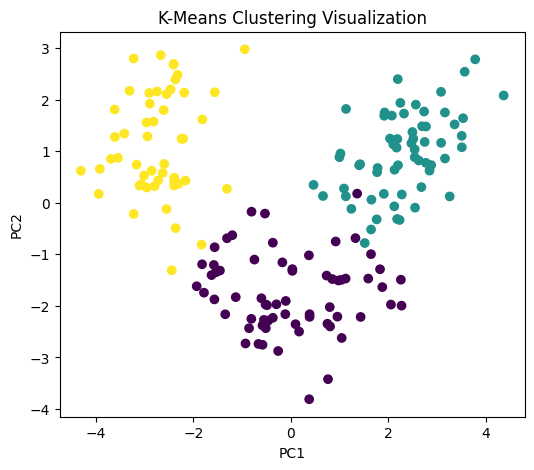

In [110]:
plt.figure(figsize=(6,5))
plt.scatter(features_2d[:,0], features_2d[:,1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering Visualization")
plt.show()

The dataset has multiple principal components, only the first two components were used for visualization. This is because graphical representation is limited to two dimensions. The clustering algorithm identified three clusters, which are clearly visible in the 2D plot.

In [ ]:
## 3. Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index

In [113]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [112]:
score = silhouette_score(features_train, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.2864118609938738


In [114]:
db_score = davies_bouldin_score(features_train, clusters)
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.3838644394308854


The clustering performance was evaluated using Silhouette Score and Davies–Bouldin Index. The Silhouette Score of 0.286 indicates moderate clustering with some overlap between clusters. The Davies–Bouldin Index of 1.38 suggests that clusters are reasonably separated but not highly distinct.

In [115]:
## 1. Apply the same clustering algorithm to the PCA-transformed dataset.

In [118]:
x_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.557162,-2.049892,-0.091349,0.765701,0.452649,0.719097,-0.592103,0.699100,0.285611
1,-0.849655,-2.213167,-0.437357,1.385915,-0.109483,0.652157,0.906626,-0.717721,-0.342738
2,-3.412289,0.125905,-0.964559,-0.003591,0.777005,0.337549,-0.161950,0.106203,-0.872797
3,-3.160322,0.679780,0.962217,-1.087190,-0.344822,1.237369,-0.562506,0.067553,0.228227
4,2.141868,0.001301,-1.064412,0.150342,-0.512459,0.456985,-0.279434,-0.253188,0.114024


In [122]:
x_train_pca.shape

(142, 9)

In [119]:
x_test_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-1.447586,-1.782905,0.790671,-0.421779,-0.647478,-0.254327,0.183470,0.015866,-0.978308
1,-1.549024,2.214042,0.316889,0.826360,-0.993935,-2.774488,-0.712156,0.738857,0.230100
2,1.640211,0.475128,-1.144778,-1.072314,-0.751634,0.482606,-0.725554,-0.763621,-0.202077
3,1.595508,-1.499795,0.278584,0.113966,1.295499,-0.288378,-0.884665,0.483204,-0.494536
4,-0.866690,2.943233,1.066746,0.975537,-0.921393,-2.861699,-0.759650,0.401286,1.155536


In [123]:
x_test_pca.shape

(36, 9)

In [121]:
## concat the x_train_pca and x_test_pca. Because we need whole data, in clsutering there is no need for train and test data
x_data = pd.concat([x_train_pca,x_test_pca],axis=0)
x_data.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.557162,-2.049892,-0.091349,0.765701,0.452649,0.719097,-0.592103,0.699100,0.285611
1,-0.849655,-2.213167,-0.437357,1.385915,-0.109483,0.652157,0.906626,-0.717721,-0.342738
2,-3.412289,0.125905,-0.964559,-0.003591,0.777005,0.337549,-0.161950,0.106203,-0.872797
3,-3.160322,0.679780,0.962217,-1.087190,-0.344822,1.237369,-0.562506,0.067553,0.228227
4,2.141868,0.001301,-1.064412,0.150342,-0.512459,0.456985,-0.279434,-0.253188,0.114024


In [124]:
x_data.shape

(178, 9)

In [125]:
kmeans_pca = KMeans(n_clusters=3,random_state=100)
kmeans_pca.fit(x_data)

KMeans(n_clusters=3, random_state=100)

In [127]:
clusters1 = kmeans_pca.labels_
clusters1

array([2, 2, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 2, 0, 2, 1, 1, 0, 0,
       2, 2, 0, 1, 0, 2, 2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
       2, 2, 2, 2, 0, 0, 2, 0, 1, 1, 0, 2, 1, 0, 1, 1, 2, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 2, 2, 2, 0, 2, 2, 0, 2, 0, 0, 2, 1, 2, 1, 2, 0, 2,
       1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 2, 1, 1, 0,
       1, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 0, 2, 2, 1, 1, 0, 0, 2,
       0, 2, 2, 1, 2, 2, 2, 2, 0, 0, 2, 1, 0, 2, 1, 1, 2, 2, 2, 0, 1, 2,
       1, 1, 1, 0, 1, 0, 2, 0, 1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 1, 2, 0, 2,
       1, 1], dtype=int32)

In [128]:
pca = PCA(n_components=2)
xdata_2d = pca.fit_transform(x_data)

In [116]:
## 2. Visualize the clustering results obtained from PCA-transformed data.

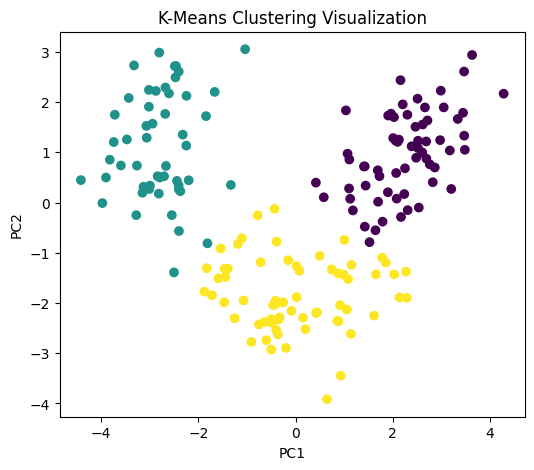

In [130]:
plt.figure(figsize=(6,5))
plt.scatter(xdata_2d[:,0], xdata_2d[:,1], c=clusters1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering Visualization")
plt.show()

The clustering algorithm identified three clusters, which are clearly visible than original data clusters in the 2D plot

In [132]:
score1 = silhouette_score(x_data, clusters1)
db_score1 = davies_bouldin_score(x_data, clusters1)
print('Silhouette Score :',score1,'Davies Bouldin Score :',db_score1)

Silhouette Score : 0.30533195597666346 Davies Bouldin Score : 1.3010839441663584


In [117]:
## 3. Compare the clustering results from PCA-transformed data with those from the original dataset.

In [134]:
dict1 = {'Methods':['Original Data','PCA transformed data'],'Silhouette Score':[score,score1],'Davies Bouldin Score':[db_score,db_score1]}
score_comp = pd.DataFrame(dict1)
score_comp

,Methods,Silhouette Score,Davies Bouldin Score
0,Original Data,0.286412,1.383864
1,PCA transformed data,0.305332,1.301084


Clustering results from the original dataset and PCA-transformed dataset were compared using Silhouette Score and Davies–Bouldin Index. The PCA-transformed data achieved a higher Silhouette Score (0.305) compared to the original data (0.286), indicating better cluster separation. Additionally, the Davies–Bouldin Index was lower for PCA-transformed data (1.301) than the original data (1.383), suggesting more compact and well-separated clusters. Therefore, PCA improved the clustering performance by reducing dimensionality and removing noise from the dataset

In [135]:
## 1. Compare the clustering results obtained from the original dataset and PCA-transformed data.

In [136]:
dict1 = {'Methods':['Original Data','PCA transformed data'],'Silhouette Score':[score,score1],'Davies Bouldin Score':[db_score,db_score1]}
score_comp = pd.DataFrame(dict1)
score_comp

,Methods,Silhouette Score,Davies Bouldin Score
0,Original Data,0.286412,1.383864
1,PCA transformed data,0.305332,1.301084


Clustering results from the original dataset and PCA-transformed dataset were compared using Silhouette Score and Davies–Bouldin Index. The PCA-transformed data achieved a higher Silhouette Score (0.305) compared to the original data (0.286), indicating better cluster separation. Additionally, the Davies–Bouldin Index was lower for PCA-transformed data (1.301) than the original data (1.383), suggesting more compact and well-separated clusters. Therefore, PCA improved the clustering performance by reducing dimensionality and removing noise from the dataset

In [ ]:
## 2. Discuss any similarities or differences observed in the clustering results.

Similarities
- Both original data and PCA-transformed data produced 3 clusters
- Major clusters are clearly identifiable in both cases

Differences

- PCA-transformed data shows slightly better separation between clusters and less overlap between data points.

In [137]:
## 3. Reflect on the impact of dimensionality reduction on clustering performance.

Dimensionality reduction using PCA improved clustering performance by removing noise and redundant features. It helped in capturing the most important variance in the data, resulting in more compact and well-separated clusters. This is reflected in the improved Silhouette Score and reduced Davies–Bouldin Index.

In [138]:
## 4. Analyze the trade-offs between using PCA and clustering directly on the original dataset.

Using PCA for clustering offers advantages such as reduced dimensionality, improved computational efficiency, and better clustering performance due to noise reduction. However, it may lead to loss of some information and reduced interpretability of features. Clustering on the original dataset retains full information and feature interpretability but may suffer from high dimensionality and noise, leading to slightly lower clustering performance.

In [139]:
## 1. Summarize the key findings and insights from the assignment.

The assignment explored the application of PCA and K-Means clustering on the dataset. PCA was used to reduce dimensionality while retaining most of the variance. It was found that 7 principal components retained over 90% of the total variance. Clustering was performed on both the original and PCA-transformed datasets. The PCA-transformed data achieved slightly better performance, with a higher Silhouette Score and a lower Davies–Bouldin Index. Visualization using PCA also showed clearer cluster separation. These results indicate that dimensionality reduction can improve clustering performance by removing noise and redundant features.

In [140]:
## 2. Discuss the practical implications of using PCA and clustering in data analysis.

PCA and clustering are widely used in real-world data analysis. PCA helps in reducing high-dimensional data into a simpler form, making it easier to visualize and process. It is especially useful when dealing with datasets with many correlated features. Clustering algorithms like K-Means are used to identify hidden patterns or group similar data points without labeled data. In practice, these techniques are used in applications such as customer segmentation, image compression, anomaly detection, and recommendation systems. Combining PCA with clustering can improve efficiency and performance, especially for large datasets.

In [141]:
## 3. Provide recommendations for when to use each technique based on the analysis conducted.

When to use PCA
- When dataset has many features (high dimensionality)
- When features are correlated or redundant
- When you need data visualization (2D/3D)
- When you want to reduce noise

When to use Clustering
- When data is unlabeled
- When you want to group similar data points
- For tasks like:
   Customer segmentation,
   Pattern discovery,
   Market analysis